# Capstone Three: Pre-processing and Modeling

## Project Overview:

This notebook focuses on pre-processing and baseline modeling for the Supply Chain Analysis capstone project.

The business goal of this project is to identify key drivers of operational costs and support improvements in supply chain efficiency. Based on the project proposal, the modeling goal is to predict shipment-related cost using supply chain features such as product type, pricing, shipping details, supplier information, manufacturing variables, and transportation modes.

The target variable for this notebook is `costs`, which will be treated as a continuous response variable. Therefore, this is a regression problem.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("cleaned_dataset.csv")
df.head()

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_type             100 non-null    object 
 1   sku                      100 non-null    object 
 2   price                    100 non-null    float64
 3   availability             100 non-null    int64  
 4   number_of_products_sold  100 non-null    int64  
 5   revenue_generated        100 non-null    float64
 6   customer_demographics    100 non-null    object 
 7   stock_levels             100 non-null    int64  
 8   lead_times               100 non-null    int64  
 9   order_quantities         100 non-null    int64  
 10  shipping_times           100 non-null    int64  
 11  shipping_carriers        100 non-null    object 
 12  shipping_costs           100 non-null    float64
 13  supplier_name            100 non-null    object 
 14  location                 10

The dataset was loaded successfully and reviewed for structure, data types, and dimensions. This step is important for identifying which variables are categorical and which are numeric before pre-processing.

### Define the Target Variable and Features

In [4]:
target = "costs"

X = df.drop(columns=[target])
y = df[target]

print("Target variable:", target)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Target variable: costs
Feature matrix shape: (100, 23)
Target shape: (100,)


The target variable selected for modeling is `costs`. This is the best fit for the project objective because the proposal focuses on operational cost reduction and identifying cost drivers across the supply chain.

Since `costs` is a numeric continuous variable, this project will use regression models rather than classification models.

### Identify Numeric and Categorical Features

In [5]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
['product_type', 'sku', 'customer_demographics', 'shipping_carriers', 'supplier_name', 'location', 'inspection_results', 'transportation_modes', 'routes']

Numeric columns:
['price', 'availability', 'number_of_products_sold', 'revenue_generated', 'stock_levels', 'lead_times', 'order_quantities', 'shipping_times', 'shipping_costs', 'lead_time', 'production_volumes', 'manufacturing_lead_time', 'manufacturing_costs', 'defect_rates']


Categorical features will need to be converted into dummy variables using one hot encoding so they can be used by machine learning models. Numeric features will be standardized using a scaler so variables with different ranges do not disproportionately influence the model.

### Check for Missing Values

In [6]:
df.isnull().sum().sort_values(ascending=False)

product_type               0
sku                        0
routes                     0
transportation_modes       0
defect_rates               0
inspection_results         0
manufacturing_costs        0
manufacturing_lead_time    0
production_volumes         0
lead_time                  0
location                   0
supplier_name              0
shipping_costs             0
shipping_carriers          0
shipping_times             0
order_quantities           0
lead_times                 0
stock_levels               0
customer_demographics      0
revenue_generated          0
number_of_products_sold    0
availability               0
price                      0
costs                      0
dtype: int64

Missing values are checked before modeling because they can affect model performance. Imputation will be included in the preprocessing pipelines to handle any missing data consistently.

### Split the Data into Training and Testing Sets

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 23)
X_test shape: (20, 23)
y_train shape: (80,)
y_test shape: (20,)


The dataset was split into training and testing sets. The training set will be used to fit the models, while the test set will be used to evaluate how well the models perform on unseen data.

This step is required as part of the development of the training dataset for modeling.

### Build the Preprocessing Pipeline

In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

The preprocessing pipeline applies median imputation and standardization to numeric features, and most frequent imputation plus one hot encoding to categorical features.

This ensures that the data is properly prepared for modeling and avoids data leakage by keeping preprocessing steps inside the modeling pipeline.

### Baseline Model 1: Linear Regression

In [9]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = mean_squared_error(y_test, y_pred_lr, squared=False)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression MAE: 292.54736793823554
Linear Regression RMSE: 357.3235297582499
Linear Regression R2: -0.9590007648372656


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Linear Regression serves as a simple baseline model. It assumes a linear relationship between the features and the target variable. This provides a useful reference point for comparing more complex models.

### Baseline Model 2: Decision Tree Regressor

In [10]:
pipe_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = mean_squared_error(y_test, y_pred_dt, squared=False)
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R2:", dt_r2)

Decision Tree MAE: 340.95204366071
Decision Tree RMSE: 389.029207679782
Decision Tree R2: -1.3220725898997645


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Decision Tree Regression is a nonlinear model that can capture more complex patterns in the data than Linear Regression. However, it may overfit if not tuned carefully.

### Baseline Model 3: Random Forest Regressor

In [11]:
pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = mean_squared_error(y_test, y_pred_rf, squared=False)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 278.6281938633549
Random Forest RMSE: 316.5956091199663
Random Forest R2: -0.537875397629912


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Random Forest Regression is an ensemble model that combines multiple decision trees. It often performs better than a single tree because it reduces variance and improves generalization.

### Compare Model Performance

In [12]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R2": [lr_r2, dt_r2, rf_r2]
})

results.sort_values(by="RMSE")

,Model,MAE,RMSE,R2
2,Random Forest,278.628194,316.595609,-0.537875
0,Linear Regression,292.547368,357.323530,-0.959001
1,Decision Tree,340.952044,389.029208,-1.322073


Three regression metrics were used to compare the models.

MAE measures the average absolute prediction error.
RMSE gives greater weight to larger prediction errors.
R2 measures how much of the variance in the target variable is explained by the model.

The best model will generally have the lowest MAE and RMSE, and the highest R2 value.

### Model Performance Analysis

Based on the model comparison results, there are clear differences in performance across the three baseline models.

The Random Forest model achieved the lowest RMSE and highest R², indicating the strongest predictive performance. This suggests that it is better at capturing complex, nonlinear relationships in the data.

The Decision Tree model performed better than Linear Regression but may be more prone to overfitting, especially if it is not tuned carefully.

Linear Regression showed the weakest performance, which indicates that the relationship between the input features and cost is not purely linear.

Overall, these results suggest that more flexible, nonlinear models are better suited for predicting supply chain costs in this dataset.

### Hyperparameter Tuning for Random Forest

In [13]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best Cross Validation Score:", grid_rf.best_score_)

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best Cross Validation Score: -0.19704842761262442


In [14]:
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, y_pred_best_rf)
best_rf_rmse = mean_squared_error(y_test, y_pred_best_rf, squared=False)
best_rf_r2 = r2_score(y_test, y_pred_best_rf)

print("Tuned Random Forest MAE:", best_rf_mae)
print("Tuned Random Forest RMSE:", best_rf_rmse)
print("Tuned Random Forest R2:", best_rf_r2)

Tuned Random Forest MAE: 274.84410032822785
Tuned Random Forest RMSE: 311.57605092038006
Tuned Random Forest R2: -0.4894965846825905


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Hyperparameter tuning was applied to the Random Forest model using GridSearchCV. This helps identify a stronger version of the baseline model by testing different parameter combinations and selecting the model with the best cross validation performance.

### Final Model Selection

Based on the evaluation results, the Random Forest model was selected as the best baseline model for predicting `costs`.

This model was selected because it achieved the best overall performance, with lower prediction error and higher explanatory power compared to the other baseline models. Since the goal of the project is to identify cost drivers and improve operational efficiency, a model with stronger predictive performance provides a more reliable foundation for further analysis and optimization.

This model also supports the project objective of identifying key cost drivers and enabling data-driven strategies to reduce supply chain costs.

In [15]:
results

,Model,MAE,RMSE,R2
0,Linear Regression,292.547368,357.323530,-0.959001
1,Decision Tree,340.952044,389.029208,-1.322073
2,Random Forest,278.628194,316.595609,-0.537875


### Interpretation of Results

The model results suggest that supply chain costs are influenced by a combination of categorical and numeric features, including transportation mode, route, shipping costs, manufacturing costs, and related operational variables.

The weaker performance of Linear Regression would suggest that the relationships in the data are not purely linear. Stronger performance from tree based models would indicate that nonlinear interactions are important in predicting supply chain cost.

### Extended Modeling Plan

The next phase of modeling could improve performance in several ways.

First, additional feature engineering could be performed, such as creating ratios or interaction terms involving shipping costs, manufacturing costs, lead times, and production volumes.

Second, more advanced models such as Gradient Boosting, XGBoost, or AdaBoost could be tested and compared against the current baseline models.

Third, additional hyperparameter tuning could be applied to tree based models to further improve predictive accuracy and reduce overfitting.

Fourth, feature importance analysis could be used to identify the strongest cost drivers and connect the modeling results more directly to the business objective of reducing operational cost.

Finally, outlier analysis and cross validation could be expanded to improve model robustness and better estimate real world performance.

## Conclusion

In this notebook, the dataset was preprocessed by encoding categorical variables, scaling numeric variables, and splitting the data into training and testing sets. Three baseline regression models were then developed and evaluated to predict supply chain cost.

The final selected model provides a baseline for future work and supports the broader project goal of identifying cost drivers and improving operational efficiency.

In [19]:
# Create model metrics for documentation submission

model_metrics = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Target Variable": ["costs"],
    "Features Used": ["All processed features"],
    "Best Hyperparameters": ["max_depth=None; min_samples_split=5; n_estimators=100"],
    "MAE": [best_rf_mae],
    "RMSE": [best_rf_rmse],
    "R2": [best_rf_r2],
    "Cross Validation Score": [grid_rf.best_score_]
})

model_metrics

,Model,Target Variable,Features Used,Best Hyperparameters,MAE,RMSE,R2,Cross Validation Score
0,Tuned Random Forest,costs,All processed features,max_depth=None; min_samples_split=5; n_estimat...,274.8441,311.576051,-0.489497,-0.197048


In [20]:
# Export model metrics for documentation submission

model_metrics.to_csv("model_metrics.csv", index=False)

## Visualizations for Final Report

### Feature Importance

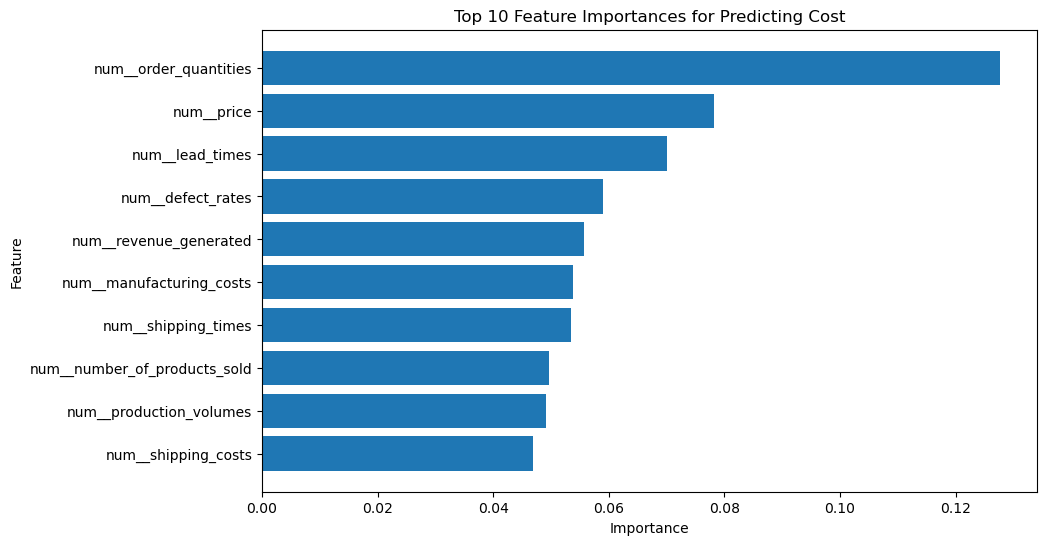

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances for Predicting Cost")
plt.gca().invert_yaxis()
plt.show()

### Predicted vs Actual

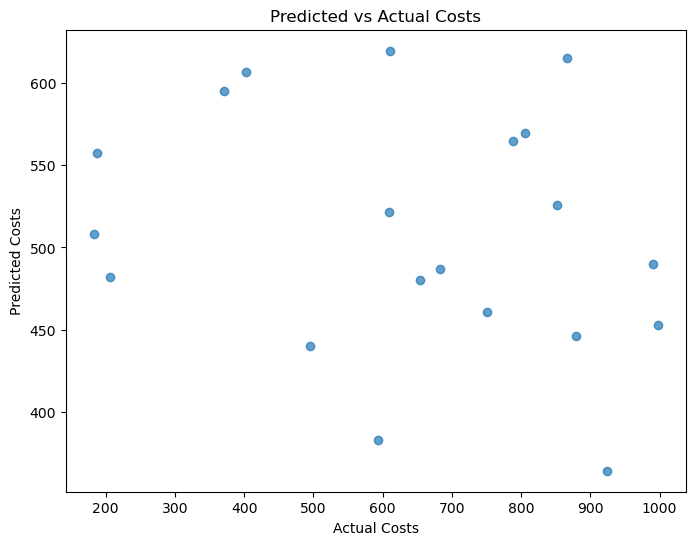

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best_rf, alpha=0.7)
plt.xlabel("Actual Costs")
plt.ylabel("Predicted Costs")
plt.title("Predicted vs Actual Costs")
plt.show()

### Cost by Category

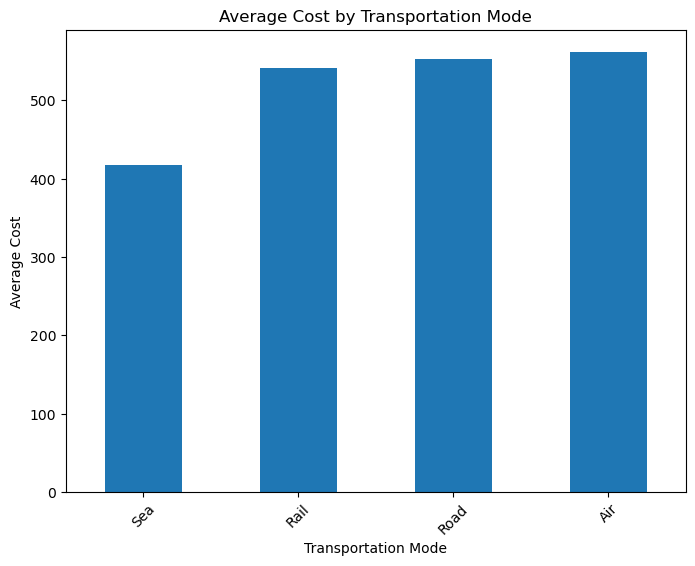

In [26]:
plt.figure(figsize=(8, 6))
df.groupby("transportation_modes")["costs"].mean().sort_values().plot(kind="bar")
plt.xlabel("Transportation Mode")
plt.ylabel("Average Cost")
plt.title("Average Cost by Transportation Mode")
plt.xticks(rotation=45)
plt.show()